In [1]:
%load_ext autoreload
%autoreload 2

In [11]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
import seaborn as sns

from scipy.stats import zscore
from functools import partial

# home-grown
import utils as ut

Create different data frames for the four variability conditions
To arrive at the four conditions, two binary variables are fully crossed:

--> participant effect (shared across people vs. individual difference)

--> time-based effect (general effect independent of learning history vs. history-dependent effect)

1. individual difference & history-dependent: original data
2. individual difference & no history: randomly shuffled trials within one given participant
3. shared across people & history-dependent: keep trial number, but shuffle participants randomly
4. shared across people & no history: shuffle trial number randomly & shuffle participants randomly

In [8]:
filter = slice(0, 4, 1)
is_download = False

if is_download:
    df_itc_all = ut.load_and_concat_raw_data(filter, )
else:
    df_itc_all = pd.read_csv("data/full-data.csv")
df_itc_all.drop("Unnamed: 0", axis=1, inplace=True)
# make participant ids unique (i.e., they were re-used across sessions, but likely not from the same participant)
df_itc_all = ut.unique_participant_ids(df_itc_all)
n_participants_total = df_itc_all["sid_unique"].nunique()
# note. all participants provided exactly 195 trials
n_trials = 195

col_pid = ["sid_unique"]
cols_x = ["right_time", "right_val", "left_time", "left_val"]
col_y = ["right_picked"]
col_y_shifted = ["right_picked_prev"]

# zscale X
df_itc_all[cols_x] = df_itc_all[cols_x].apply(zscore)

df_itc_original, df_itc_id_nohist, df_itc_shared_hist, df_itc_shared_nohist = ut.make_conditions(
    df_itc_all, n_trials, n_participants_total)


In [9]:
l_dfs = list(map(ut.shift_y, [df_itc_original, df_itc_id_nohist, df_itc_shared_hist, df_itc_shared_nohist]))
df_itc_original, df_itc_id_nohist, df_itc_shared_hist, df_itc_shared_nohist = l_dfs[0], l_dfs[1], l_dfs[2], l_dfs[3]

In [33]:
partial_split_and_format = partial(
    ut.split_and_format, splittype="first_vs_second_half", n_trial_split=100,
    col_pid = col_pid, cols_x = cols_x, col_y = col_y, col_y_shifted=col_y_shifted
)

l_df_train_dev = list(map(
    partial_split_and_format, 
    [df_itc_original, df_itc_id_nohist, df_itc_shared_hist, df_itc_shared_nohist],
    ["original", "id_nohist", "shared_hist", "shared_nohist"]
))


In [36]:
l_df_train_dev[0].keys()

dict_keys(['condition', 'df_train', 'df_dev', 'X_train', 'y_train', 'X_dev', 'y_dev'])

# takes about 20s to load for all four data sets
# load all four data frames and concat into one df
# each data frame from a different 2020 month (i.e., march, april, june, november)

filter = slice(0, 4, 1)
df_itc_all = ut.load_and_concat_raw_data(filter)
df_itc_all.drop("Unnamed: 0", axis=1, inplace=True)

df_itc_all.to_csv("data/full-data.csv")

In [13]:
df_itc_all = pd.read_csv("data/full-data.csv")

In [14]:
df_itc_all.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,absolute_value_diff,right_picked,sid,month
0,0,42,2.666667,21,0.666667,0,4,21,21,4.0,2.0,1,1,March
1,1,0,33.333333,50,133.333333,0,4,50,0,4.0,100.0,0,1,March
2,2,9,1500.000000,7,1000.000000,0,4,2,7,1.5,500.0,1,1,March
3,3,0,1000.000000,1,1100.000000,0,4,1,0,1.1,100.0,0,1,March
4,4,7,50.000000,11,55.000000,0,4,4,7,1.1,5.0,0,1,March


In [15]:
participant_ids = df_itc_all["sid"].unique()
participant_ids_sample = pd.DataFrame({"sid":np.random.choice(participant_ids, size=500)})
#df_itc_subset = pd.merge(participant_ids_sample, df_itc_all, how="left", on="sid")

In [16]:
df_itc_all["value_diff"] = np.round(df_itc_all["right_val"] - df_itc_all["left_val"], 1)
df_itc_all["absolute_time_diff"] = df_itc_all["time_diff"].copy()
df_itc_all["time_diff"] = np.round(df_itc_all["right_time"] - df_itc_all["left_time"], 0)

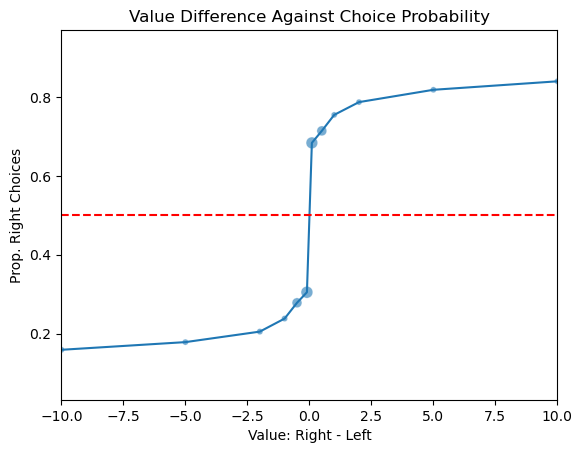

In [17]:
df_valdiff_agg = df_itc_all.groupby("value_diff").aggregate({"right_picked": ["count", "mean"]}).reset_index()
df_valdiff_agg.columns = ['_'.join(col).strip() for col in df_valdiff_agg.columns.to_flat_index()]
df_valdiff_agg.columns = df_valdiff_agg.columns.str.rstrip('_')
sns.lineplot(data=df_valdiff_agg, x="value_diff", y="right_picked_mean")

# Overlay scatter plot with size mapped to variable "x"
sns.scatterplot(
    data=df_valdiff_agg,
    x="value_diff",
    y="right_picked_mean",
    size="right_picked_count",              # map size to variable "x"
    legend=False,          # optional: hide size legend
    alpha=0.6              # optional: transparency
)
plt.xlim((-10, 10))
plt.xlabel("Value: Right - Left")
plt.ylabel("Prop. Right Choices")
plt.title("Value Difference Against Choice Probability")
_ = plt.axhline(y=.5, color="red", linestyle="--")

In [18]:
df_itc_all["value_diff_bin_labels"] = pd.cut(df_itc_all["value_diff"], np.array([-1001, -24, -2.3, 0, 2.3, 24, 1001]))
df_itc_all["value_diff_bin_values"] = pd.cut(df_itc_all["value_diff"], np.array([-1001, -24, -2.3, 0, 2.3, 24, 1001]), labels=False)

In [19]:
df_lookup_valdiff = df_itc_all[["value_diff_bin_labels", "value_diff_bin_values"]].drop_duplicates().sort_values("value_diff_bin_values").reset_index(drop=True)
df_lookup_valdiff

,value_diff_bin_labels,value_diff_bin_values
0,"(-1001.0, -24.0]",0
1,"(-24.0, -2.3]",1
2,"(-2.3, 0.0]",2
3,"(0.0, 2.3]",3
4,"(2.3, 24.0]",4
5,"(24.0, 1001.0]",5


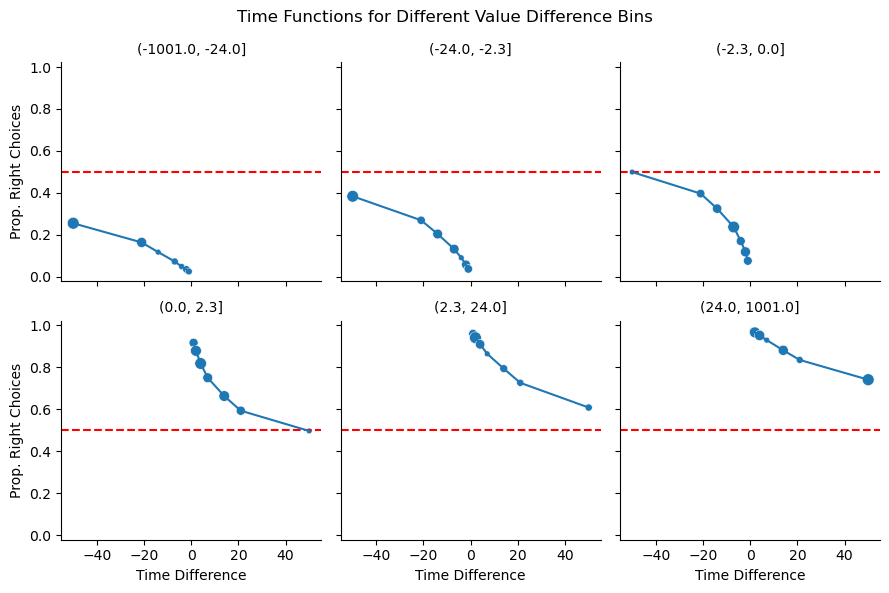

In [20]:
df_timediff_agg = df_itc_all.groupby(
    ["time_diff", "value_diff_bin_values"]).aggregate(
    {"right_picked": ["count", "mean"]}).reset_index()
df_timediff_agg.columns = ['_'.join(col).strip() for col in df_timediff_agg.columns.to_flat_index()]
df_timediff_agg.columns = df_timediff_agg.columns.str.rstrip('_')
df_timediff_agg = pd.merge(df_timediff_agg, df_lookup_valdiff, how="left", on="value_diff_bin_values")

g = sns.FacetGrid(data=df_timediff_agg, col="value_diff_bin_labels", col_wrap=3, )

# Add reference lines
for ax in g.axes.flat:
    ax.axhline(y=.5, color="red", linestyle="--")

# Line connecting the data points
g.map_dataframe(sns.lineplot, x="time_diff", y="right_picked_mean")

# Overlay dots with size info
g.map_dataframe(sns.scatterplot, x="time_diff", y="right_picked_mean", size="right_picked_count", marker="o", legend=False)

# Titles and layout
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Time Difference", "Prop. Right Choices")
g.fig.suptitle("Time Functions for Different Value Difference Bins")
plt.tight_layout()
plt.show()

In [ ]:
# all participants contributed 195 data points per session
# some particpiants participated in up to 4 sessions
# unlikely that > 3000 participants completed all 4 parts
# therefore, only use by-session participant ids as belonging to the same participant
(df_itc_all.value_counts("sid") / 195).unique()
# only full datasets of 195 trials

In [21]:
month_order = ["March", "April", "June", "November"]

# Convert the 'month' column to a Categorical type with that specific order
df_ids = pd.DataFrame(df_itc_all.groupby("month")["sid"].max()).reset_index()
df_ids["month"] = pd.Categorical(df_ids["month"], categories=month_order, ordered=True)
df_ids.sort_values("month", inplace=True)
df_ids["sid_prev"] = df_ids["sid"].cumsum()
df_ids["sid_continue"] = df_ids["sid_prev"].shift(1).fillna(0)

In [22]:
df_ids

,month,sid,sid_prev,sid_continue
2,March,3335,3335,0.0
0,April,3195,6530,3335.0
1,June,3216,9746,6530.0
3,November,3159,12905,9746.0


In [23]:
df_itc_all = pd.merge(df_itc_all, df_ids.drop(columns=["sid", "sid_prev"]), how="left", on="month")
df_itc_all["sid_unique"] = (df_itc_all["sid"] + df_itc_all["sid_continue"]).astype(int)

In [24]:
# Map each value to a unique integer starting from 1
unique_vals = df_itc_all["sid_unique"].unique()
mapping = {val: idx + 1 for idx, val in enumerate(unique_vals)}

# Convert the series using the mapping
df_itc_all["sid_unique"] = df_itc_all["sid_unique"].map(mapping).astype("category").astype(int)

n_participants_total = df_itc_all["sid_unique"].nunique()
n_trials = 195

1. individual difference & history: original data set

In [25]:
df_itc_all["trial_id"] = df_itc_all.groupby("sid_unique").cumcount() + 1
df_itc_all_original = df_itc_all.copy()
df_itc_all_original.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,...,right_picked,sid,month,value_diff,absolute_time_diff,value_diff_bin_labels,value_diff_bin_values,sid_continue,sid_unique,trial_id
0,0,42,2.666667,21,0.666667,0,4,21,21,4.0,...,1,1,March,2.0,21,"(0.0, 2.3]",3,0.0,1,1
1,1,0,33.333333,50,133.333333,0,4,-50,0,4.0,...,0,1,March,-100.0,50,"(-1001.0, -24.0]",0,0.0,1,2
2,2,9,1500.000000,7,1000.000000,0,4,2,7,1.5,...,1,1,March,500.0,2,"(24.0, 1001.0]",5,0.0,1,3
3,3,0,1000.000000,1,1100.000000,0,4,-1,0,1.1,...,0,1,March,-100.0,1,"(-1001.0, -24.0]",0,0.0,1,4
4,4,7,50.000000,11,55.000000,0,4,-4,7,1.1,...,0,1,March,-5.0,4,"(-24.0, -2.3]",1,0.0,1,5


2. individual difference & no history: randomly shuffled trials within one given participant

In [26]:
df_itc_all_id_nohist = df_itc_all.copy()
df_itc_all_id_nohist["trial_id_old"] = df_itc_all_id_nohist["trial_id"].copy()
df_itc_all_id_nohist = df_itc_all_id_nohist.groupby("sid_unique").sample(frac=1).reset_index(drop=True)
df_itc_all_id_nohist["trial_id"] = df_itc_all_id_nohist.groupby("sid_unique").cumcount() + 1
df_itc_all_id_nohist.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,...,sid,month,value_diff,absolute_time_diff,value_diff_bin_labels,value_diff_bin_values,sid_continue,sid_unique,trial_id,trial_id_old
0,21,54,5000.000000,50,4000.000000,0,4,4,50,1.25,...,1,March,1000.0,4,"(24.0, 1001.0]",5,0.0,1,1,22
1,20,64,66.666667,50,16.666667,0,4,14,50,4.00,...,1,March,50.0,14,"(24.0, 1001.0]",5,0.0,1,2,21
2,189,2,55.000000,0,50.000000,0,4,2,0,1.10,...,1,March,5.0,2,"(2.3, 24.0]",4,0.0,1,3,190
3,55,0,1.000000,2,1.500000,0,4,-2,0,1.50,...,1,March,-0.5,2,"(-2.3, 0.0]",2,0.0,1,4,56
4,124,0,1.000000,1,3.000000,0,4,-1,0,3.00,...,1,March,-2.0,1,"(-2.3, 0.0]",2,0.0,1,5,125


3. shared across people & history: randomly shuffle participant ids

In [27]:
# first separate by condition and then shuffle to shuffle within condition
df_itc_all_shared_hist = df_itc_all.copy()
df_itc_all_shared_hist["sid_unique_old"] = df_itc_all_shared_hist["sid_unique"].copy()
df_itc_all_shared_hist = df_itc_all_shared_hist.groupby("trial_id").sample(frac=1).reset_index(drop=True)
df_itc_all_shared_hist["sid_unique"] = df_itc_all_shared_hist.groupby("trial_id").cumcount() + 1
df_itc_all_shared_hist.sort_values(["sid_unique", "trial_id"], inplace=True)
df_itc_all_shared_hist.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,...,sid,month,value_diff,absolute_time_diff,value_diff_bin_labels,value_diff_bin_values,sid_continue,sid_unique,trial_id,sid_unique_old
0,1337505,2,20000.0,3,21000.0,0,3,-1,2,1.05,...,94,November,-1000.0,1,"(-1001.0, -24.0]",0,9746.0,1,1,6860
9062,1009126,0,50.0,7,150.0,0,0,-7,0,3.00,...,862,June,-100.0,7,"(-1001.0, -24.0]",0,6530.0,1,2,5176
18124,853322,2,50.0,23,75.0,0,4,-21,2,1.50,...,2863,April,-25.0,21,"(-1001.0, -24.0]",0,3335.0,1,3,4377
27186,108813,4,2000.0,18,2500.0,0,2,-14,4,1.25,...,837,March,-500.0,14,"(-1001.0, -24.0]",0,0.0,1,4,559
36248,1183069,0,50.0,2,150.0,0,0,-2,0,3.00,...,2171,June,-100.0,2,"(-1001.0, -24.0]",0,6530.0,1,5,6068


4. shared across people & no history: shuffle trial number randomly & shuffle participants randomly

In [28]:
df_itc_all_shared_nohist = df_itc_all.copy()
df_itc_all_shared_nohist["trial_id_old"] = df_itc_all_shared_nohist["trial_id"].copy()
df_itc_all_shared_nohist["sid_unique_old"] = df_itc_all_shared_nohist["sid_unique"].copy()
df_itc_all_shared_nohist = df_itc_all_shared_nohist.sample(frac=1).reset_index(drop=True)
df_itc_all_shared_nohist["trial_id"] = np.tile(range(1, n_trials+1), n_participants_total)
df_itc_all_shared_nohist["sid_unique"] = np.tile(range(1, n_participants_total + 1), n_trials)
df_itc_all_shared_nohist.sort_values(["sid_unique", "trial_id"], inplace=True)
df_itc_all_shared_nohist.head()

,Unnamed: 0,right_time,right_val,left_time,left_val,att_check,condition,time_diff,sooner_time,relative_value_diff,...,month,value_diff,absolute_time_diff,value_diff_bin_labels,value_diff_bin_values,sid_continue,sid_unique,trial_id,trial_id_old,sid_unique_old
0,514525,4,5000.000000,25,5500.000000,0,1,-21,4,1.10,...,April,-500.0,21,"(-1001.0, -24.0]",0,3335.0,1,1,116,2639
480286,1387410,28,25.000000,21,20.000000,0,1,7,21,1.25,...,November,5.0,7,"(2.3, 24.0]",4,9746.0,1,2,181,7115
960572,221963,18,10100.000000,4,10000.000000,0,2,14,4,1.01,...,March,100.0,14,"(24.0, 1001.0]",5,0.0,1,3,54,1139
1440858,864398,14,20.000000,35,21.000000,0,3,-21,14,1.05,...,April,-1.0,21,"(-2.3, 0.0]",2,3335.0,1,4,159,4433
154054,669506,50,8.333333,51,33.333333,0,2,-1,50,4.00,...,April,-25.0,1,"(-1001.0, -24.0]",0,3335.0,1,5,72,3434


In [56]:
X_original, y_original = ut.format_to_torch(df_itc_all_original, col_pid, cols_x, col_y)
X_id_nohist, y_id_nohist = ut.format_to_torch(df_itc_all_id_nohist, col_pid, cols_x, col_y)
X_shared_hist, y_shared_hist = ut.format_to_torch(df_itc_all_shared_hist, col_pid, cols_x, col_y)
X_shared_nohist, y_shared_nohist = ut.format_to_torch(df_itc_all_shared_nohist, col_pid, cols_x, col_y)